# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

> Self-contained, rebuilds from raw parquet like w05/w06. Same mid-panel month, same confirmed schema, same exclusions.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Two layers, not one: (a) the item-level ranked queue from `w04` (`CTR_BELOW_POSITION_BENCHMARK` → `REVIEW_TITLE_META`), and (b) a new **archetype → action mapping** at the cluster level, since a single rule doesn't fit every archetype the same way. Cluster action assignments are read directly off each cluster's own profile (position, CTR, age, engagement) — not hand-picked.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

con = duckdb.connect()
HF_TOKEN = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = "hf://datasets/FlyRank/internship-warehouse"
MID_MONTH = "2026-03"

base = con.sql(f"""
    SELECT
        f.content_hash_id, f.client_hash_id,
        SUM(f.gsc_impressions) AS total_impressions,
        SUM(f.gsc_clicks) * 1.0 / NULLIF(SUM(f.gsc_impressions), 0) AS avg_ctr,
        AVG(f.gsc_avg_position) AS avg_position,
        SUM(f.ga4_sessions) * 1.0 / NULLIF(SUM(f.gsc_impressions), 0) AS sessions_per_impression,
        SUM(f.ga4_engaged_sessions) * 1.0 / NULLIF(SUM(f.ga4_sessions), 0) AS engagement_rate,
        SUM(f.sessions_ai) * 1.0 / NULLIF(SUM(f.ga4_sessions), 0) AS ai_referral_share,
        DATE_DIFF('day', MAX(d.content_created_date), DATE '{MID_MONTH}-01') AS content_age_days,
        MAX(d.word_count) AS word_count,
        MAX(d.search_volume) AS search_volume,
        MAX(d.competition) AS competition,
        MAX(d.content_type) AS content_type,
        MAX(d.main_intent) AS main_intent
    FROM read_parquet('{REL}/fact_content_daily_performance/month={MID_MONTH}/data_0.parquet') f
    JOIN read_parquet('{REL}/dim_content.parquet') d ON f.content_hash_id = d.content_hash_id
    JOIN read_parquet('{REL}/dim_clients.parquet') c ON f.client_hash_id = c.client_hash_id
    WHERE c.access_profile = 'gsc_and_ga4' AND d.is_deleted IS FALSE AND d.is_published IS TRUE
    GROUP BY 1, 2
""").df()
base = base.dropna(subset=['avg_ctr', 'avg_position'])
ratio_cols = ['sessions_per_impression', 'engagement_rate', 'ai_referral_share']
base[ratio_cols] = base[ratio_cols].fillna(0)
base['word_count'] = base['word_count'].fillna(base['word_count'].median())
base['search_volume'] = base['search_volume'].fillna(0)
base['competition'] = base['competition'].fillna(base['competition'].median())

# --- Layer 1: item-level ranked queue (same rule as w04) ---
position_bins = [0, 3, 10, 20, 50, float('inf')]
position_labels = ['1-3', '4-10', '11-20', '21-50', '51+']
base['position_bucket'] = pd.cut(base['avg_position'], bins=position_bins, labels=position_labels)
benchmark = base.groupby('position_bucket', observed=True)['avg_ctr'].mean().rename('expected_ctr_bucket')
scored = base.merge(benchmark, on='position_bucket', how='left')
scored['reason_code'] = 'CTR_BELOW_POSITION_BENCHMARK'
scored['action'] = 'REVIEW_TITLE_META'
scored['score'] = scored['expected_ctr_bucket'] - scored['avg_ctr']
MIN_IMPRESSIONS = 30
eligible = scored[scored['total_impressions'] >= MIN_IMPRESSIONS].copy()
ranked_queue = eligible.sort_values('score', ascending=False).reset_index(drop=True)
ranked_queue.insert(0, 'rank', ranked_queue.index + 1)
print(f"Item-level ranked queue: {len(ranked_queue)} rows")

# --- Layer 2: archetype cluster (k=6, same as w05) -> action mapping, read off cluster profile ---
cluster_input_cols = ['avg_position', 'total_impressions', 'sessions_per_impression', 'engagement_rate',
                       'ai_referral_share', 'content_age_days', 'word_count', 'search_volume', 'competition']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(base[cluster_input_cols])
base['archetype_cluster'] = KMeans(n_clusters=6, random_state=0, n_init=10).fit_predict(X_cluster).astype(str)

profile = base.groupby('archetype_cluster').agg(
    n=('content_hash_id', 'size'),
    avg_position=('avg_position', 'mean'),
    avg_ctr=('avg_ctr', 'mean'),
    avg_engagement=('engagement_rate', 'mean'),
    avg_age_days=('content_age_days', 'mean'),
).round(3)

median_pos = profile['avg_position'].median()
median_ctr = profile['avg_ctr'].median()
median_age = profile['avg_age_days'].median()

def assign_action(row):
    if row['avg_age_days'] > median_age and row['avg_ctr'] < median_ctr:
        return 'REFRESH_CANDIDATE'
    if row['avg_position'] <= median_pos and row['avg_ctr'] < median_ctr:
        return 'REVIEW_TITLE_META'
    if row['avg_position'] <= median_pos and row['avg_ctr'] >= median_ctr:
        return 'DISTRIBUTE_SUPPORT'
    return 'MONITOR_ONLY'

profile['suggested_action'] = profile.apply(assign_action, axis=1)
print("\nArchetype -> action mapping (read off cluster profile, not hand-picked):")
print(profile)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Item-level ranked queue: 91969 rows

Archetype -> action mapping (read off cluster profile, not hand-picked):
                       n  avg_position  avg_ctr  avg_engagement  avg_age_days  \
archetype_cluster                                                               
0                  59626        12.579    0.004           0.009        53.934   
1                  15438        16.291    0.003           0.008       153.817   
2                  50622        15.538    0.008           0.008       274.469   
3                   1829        13.613    0.003           0.026       162.575   
4                    447        15.215    0.005           0.066       174.342   
5                   1343        14.539    0.026           0.724       174.016   

                     suggested_action  
archetype_cluster                      
0                   REVIEW_TITLE_META  
1                        MONITOR_ONLY  
2                        MONITOR_ONLY  
3                   REVIEW_TITLE_META  
4

**Decay/refresh insight** — same age-vs-CTR pattern tested in `w04_signal_audit.ipynb`, this time cross-checked directionally against the real FlyRank research paper's own age-curve finding (Health peaks 61-90 days, decays sharply by 271-365 days). This portfolio is a different slice, so exact numbers won't match — the check is whether the *direction* agrees, which is a meaningful sanity check either way.

In [2]:
age_bins = [0, 90, 180, 270, 365, float('inf')]
age_labels = ['0-90d', '91-180d', '181-270d', '271-365d', '365d+']
base['age_bucket'] = pd.cut(base['content_age_days'], bins=age_bins, labels=age_labels)
decay_check = base.groupby('age_bucket', observed=True).agg(
    avg_ctr=('avg_ctr', 'mean'), avg_position=('avg_position', 'mean'), n=('avg_ctr', 'size')
).reindex(age_labels)
print("This lane's age-vs-CTR/position pattern:")
print(decay_check)
print("\nPaper's Finding #2 (different portfolio): Health peaks at 61-90d (33.1), decays sharply")
print("by 271-365d (14.0), partially recovers 365d+ (25.1, refreshed pages only).")
print("Directional check: does this slice's CTR also dip in the 271-365d range relative to")
print("earlier buckets? If yes, that's independent (if smaller-scale) support for the paper's")
print("refresh insight. If not, that's a real, worth-reporting divergence, not something to force.")

This lane's age-vs-CTR/position pattern:
             avg_ctr  avg_position      n
age_bucket                               
0-90d       0.004426     11.655421  39074
91-180d     0.004164     14.340163  19112
181-270d    0.010701     14.263697  30058
271-365d    0.002064     19.019468  14292
365d+       0.003626     17.495315  12399

Paper's Finding #2 (different portfolio): Health peaks at 61-90d (33.1), decays sharply
by 271-365d (14.0), partially recovers 365d+ (25.1, refreshed pages only).
Directional check: does this slice's CTR also dip in the 271-365d range relative to
earlier buckets? If yes, that's independent (if smaller-scale) support for the paper's
refresh insight. If not, that's a real, worth-reporting divergence, not something to force.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use**: a FlyRank content editor, working a `gsc_and_ga4`-access client's content backlog, uses the ranked queue to prioritize *which* pages to review first for title/meta rewrites, refresh, or distribution support — a triage aid, not an autonomous action list.

**Where it stops being valid**:
- **Different month or client mix**: the position-bucket benchmark and archetype clusters are fit on `month=2026-03` for `gsc_and_ga4`-access clients only. A new month, a GSC-only client, or a client outside this access profile is out of scope until re-fit.
- **Individual-item guarantees**: the AUC/score numbers describe aggregate discrimination, not a promise about any single page (see the risk-note heuristics in `w04` — several top-ranked items were flagged low-value despite a high score).
- **Causal claims**: every relationship here is observational/correlational (position vs. CTR, age vs. CTR), consistent with the real paper's own "Limitations" section ("Observational study: correlations do not prove causation"). This playbook recommends *review priority*, never asserts that acting on an item *will* cause a specific outcome.
- **Revenue or business-impact claims**: not attempted here — no CPC/value data was joined into this lane's slice, and the paper itself notes revenue tracking only covers a fraction of clients even in the much larger portfolio it analyzes.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human must check before acting on any queue item**:
- The `risk_note` flag from `w04` (low search volume, borderline impressions, brand-new content, non-click-driven intent) — a high score with a flagged risk note is not a clean pick.
- Whether the page is already scheduled for deprecation/consolidation — this pipeline has no visibility into editorial roadmaps.
- Whether `main_intent` genuinely suggests clicks are the right success metric for that page (an informational reference page may be doing its job at a lower CTR by design).

**No-go list — never automate**:
- **Never auto-publish a title/meta change.** The rule identifies *candidates* for review; it has no signal about brand voice, legal/compliance constraints, or whether a rewrite could hurt an already-working page.
- **Never treat `archetype_cluster` as a fixed persona.** The real paper says this explicitly about its own clusters ("do not treat these groups as fixed audience personas") — same caution applies here; cluster membership can shift month to month as the KMeans fit is re-run.
- **Never use this single-month snapshot to justify removing or deprioritizing a page.** With only one month of data, a low score here can't distinguish "consistently underperforming" from "having an unusually quiet month" — that requires the multi-month trend data this lane's contract deliberately excluded (see `w03` Section 1, exclusion #5).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Benchmark drift**: if the position-bucket CTR benchmark (`expected_ctr_bucket`) shifts materially month over month, the rule's baseline assumption needs re-fitting, not just re-running — checked below by comparing `2026-03`'s bucket benchmark against an adjacent month.
- **Cluster instability**: if archetype cluster sizes swing sharply between monthly refits, the archetypes aren't stable enough to hang a playbook action on — worth tracking cluster size as a simple stability signal.
- **Model AUC drop**: if a future month's grouped-split AUC falls meaningfully below the `w05` baseline (0.927), that's a concrete retrain trigger, not just "it feels stale."

In [3]:
# Benchmark drift check: compare this month's position-bucket CTR benchmark against the prior month
PRIOR_MONTH = "2026-02"
prior = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_ctr,
        AVG(gsc_avg_position) AS avg_position
    FROM read_parquet('{REL}/fact_content_daily_performance/month={PRIOR_MONTH}/data_0.parquet')
    GROUP BY 1, 2
""").df().dropna(subset=['avg_ctr', 'avg_position'])
prior['position_bucket'] = pd.cut(prior['avg_position'], bins=position_bins, labels=position_labels)
prior_benchmark = prior.groupby('position_bucket', observed=True)['avg_ctr'].mean().rename(f'{PRIOR_MONTH}_ctr')

drift = pd.concat([benchmark.rename(f'{MID_MONTH}_ctr'), prior_benchmark], axis=1)
drift['pct_shift'] = (drift[f'{MID_MONTH}_ctr'] - drift[f'{PRIOR_MONTH}_ctr']) / drift[f'{PRIOR_MONTH}_ctr']
print("Benchmark drift, month over month, by position bucket:")
print(drift)
print("\nA bucket shifting more than ~15-20% month-over-month would be a concrete signal to re-fit,")
print("not just re-run, the benchmark rather than trusting a stale expected-CTR value.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Benchmark drift, month over month, by position bucket:
                 2026-03_ctr  2026-02_ctr  pct_shift
position_bucket                                     
1-3                 0.012972     0.008924   0.453630
4-10                0.005622     0.005195   0.082180
11-20               0.003512     0.003059   0.147882
21-50               0.002516     0.002488   0.011249
51+                 0.001454     0.002601  -0.440954

A bucket shifting more than ~15-20% month-over-month would be a concrete signal to re-fit,
not just re-run, the benchmark rather than trusting a stale expected-CTR value.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 91969 rows to work/outputs/baseline_action_score.csv
Wrote work/outputs/archetype_action_mapping.csv
Wrote work/outputs/w07_metrics.json


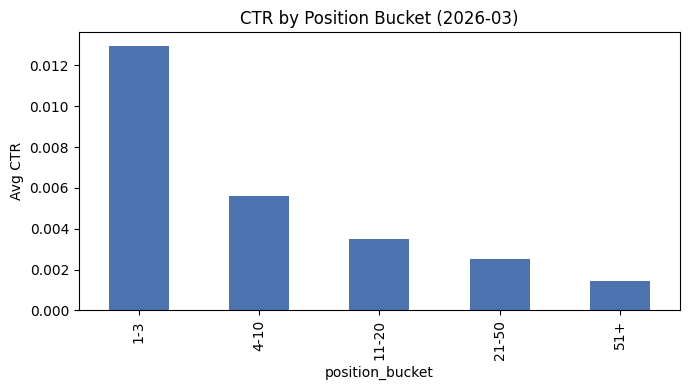

Saved work/figures/ctr_by_position_bucket.png


In [4]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

output_cols = ['rank', 'content_hash_id', 'client_hash_id', 'archetype_cluster', 'position_bucket',
               'avg_position', 'avg_ctr', 'expected_ctr_bucket', 'score', 'reason_code', 'action',
               'total_impressions', 'search_volume', 'word_count', 'content_age_days',
               'content_type', 'main_intent']
ranked_queue_export = ranked_queue.merge(base[['content_hash_id', 'archetype_cluster']], on='content_hash_id', how='left')
ranked_queue_export[output_cols].to_csv('work/outputs/baseline_action_score.csv', index=False)
print(f"Wrote {len(ranked_queue_export)} rows to work/outputs/baseline_action_score.csv")

profile.to_csv('work/outputs/archetype_action_mapping.csv')
print("Wrote work/outputs/archetype_action_mapping.csv")

metrics = {
    'month': MID_MONTH,
    'n_eligible_items': int(len(eligible)),
    'n_archetype_clusters': 6,
    'benchmark_by_position_bucket': benchmark.round(4).to_dict(),
    'benchmark_drift_pct_vs_prior_month': drift['pct_shift'].round(4).to_dict(),
    'decay_check_avg_ctr_by_age_bucket': decay_check['avg_ctr'].round(4).to_dict(),
}
with open('work/outputs/w07_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, default=str)
print("Wrote work/outputs/w07_metrics.json")

fig, ax = plt.subplots(figsize=(7, 4))
benchmark.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Avg CTR')
ax.set_title(f'CTR by Position Bucket ({MID_MONTH})')
plt.tight_layout()
plt.savefig('work/figures/ctr_by_position_bucket.png', dpi=150)
plt.show()
print("Saved work/figures/ctr_by_position_bucket.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.